# 인공 신경망
입력 데이터와 출력 데이터 사이의 관계를 가장 잘 표현한 weight와 bias 값을 찾는 것


1. 입력 데이터를 신경망에 넣고 출력값을 계산
2. 출력값과 실제값(정답) 사이의 오차(손실)를 계산
3. 이 오차를 신경망의 최종 층에서 역방향으로 전파시키면서 각 층의 가중치에 대한 기울기(미분값)를 계산
4. 계산된 기울기 값에 학습률을 곱하여 각 가중치를 업데이트
5. 이 과정을 데이터셋 전체에 대해 반복적으로 수행하면서 가중치를 점진적으로 최적화


- 활성화 함수 (activation function)  
특징을 더 잘 찾기 위해서 비선형 -> 선형으로 바꿔준다  

- 손실 함수  
예측값과 실제값 사이의 차이를 계산

- 역전파 (backpropagation)  
기울기를 계산

- 최적화 함수 (Optimizer)  
손실 함수를 최소화 하기 위해 사용되는 알고리즘
Backpropagation으로 계산된 기울기를 사용해 가중치 업데이트  
모델의 가중치 업데이트 하면서 최적화

- 에폭 (Epoch)
모든 데이터 셋을 한 번 학습  
데이터셋을 batch size 크기로 쪼개서 학습할 수 있음

# 활성화 함수 종류
(비선형이어야 함)
- 시그모이드 함수
- 계단 함수
- Relu 함수

1. 은닉층 activation func: ReLU
2. 출력층 activation func
문제 유형에 따라
- 출력층이 하나(이진 분류): sigmoid  
- 마지막 출력층이 두 개 이상이라면(다중 분류): softmax
- 회귀: Linear(활성화 함수 없음)
3. `손실함수`설정
- 이진 분류: BCEWithLogitsLoss(출력층 sigmoid 내부적으로 구현)
- 다중 분류: CrossEntropyLoss(출력층 softmax 내부적으로 구현)
- 회귀: MSELoss, MAELoss

손실함수가 처리해주기 때문에 출력층에서 sigmoid, softmax 구현할 필요 없음

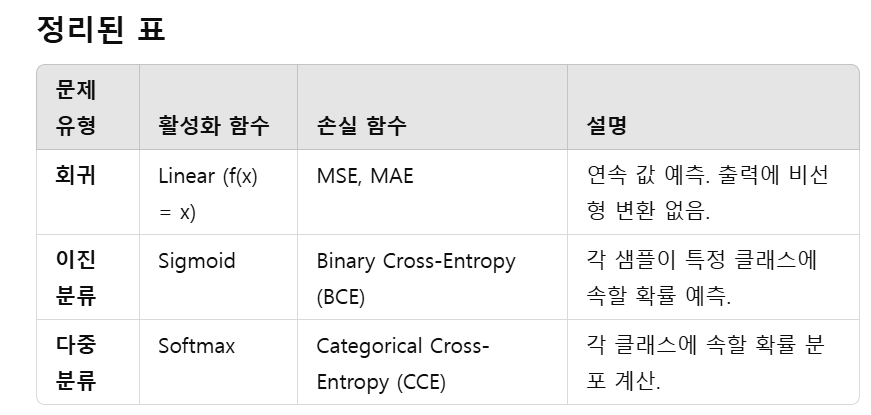

출력층 활성화 함수
- 분류 : 카테고리(클래스) 예측(소프트 맥스)
- 회귀 : 연속적인 수치 중 예측(항등 함수)

소프트맥스 함수를 적용하거나 적용하지 않더라도 가장 큰 출력값의 위치는 바뀌지 않기 때문에 출력값의 확률 표현이 필요없고 클래스 인덱스만 필요하다면 소프트맥스를 계산하지 않아도 된다.

학습과 추론 두 단계 중 학습 시에(손실 함수 계산을 위해)만 소프트맥스를 사용하는 경우가 많다.

# 배치 batch
대용량 데이터를 한꺼번에 넣고 학습시키기 힘들다
-> 학습할 데이터를 배치 단위로 쪼개서 학습시킨다

장점
- 계산 효율성(gpu를통한 병렬 처리를 통해 학습 속도 향상)
- 메모리 관리(메모리 사용량 줄임)
- 일반화 성능 향상

# iris 데이터로
(분류)

In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

False

In [ ]:
from sklearn.datasets import load_iris

load_iris()

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
X = load_iris().data
y = load_iris().target

## train, test 나누기

In [ ]:
from sklearn.model_selection import train_test_split

train_X, test_X = train_test_split(X, test_size=0.2, random_state=123)
train_y, test_y = train_test_split(y, test_size=0.2, random_state=123)

In [ ]:
len(train_X), len(test_X), len(train_y), len(test_y)

(120, 30, 120, 30)

In [ ]:
train_X

array([[7.4, 2.8, 6.1, 1.9],
       [6. , 2.2, 5. , 1.5],
       [4.7, 3.2, 1.6, 0.2],
       [5.1, 3.5, 1.4, 0.2],
       [6. , 2.2, 4. , 1. ],
       [5. , 2.3, 3.3, 1. ],
       [7.9, 3.8, 6.4, 2. ],
       [5.4, 3.9, 1.7, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.8, 2.7, 3.9, 1.2],
       [5. , 2. , 3.5, 1. ],
       [5. , 3.2, 1.2, 0.2],
       [6.8, 3.2, 5.9, 2.3],
       [6.7, 3. , 5.2, 2.3],
       [5.8, 2.7, 5.1, 1.9],
       [5.8, 2.8, 5.1, 2.4],
       [6.3, 3.4, 5.6, 2.4],
       [5.5, 2.3, 4. , 1.3],
       [5.1, 3.8, 1.5, 0.3],
       [4.4, 3. , 1.3, 0.2],
       [6.5, 3.2, 5.1, 2. ],
       [5.1, 3.3, 1.7, 0.5],
       [4.9, 3.1, 1.5, 0.1],
       [6.7, 3.1, 4.7, 1.5],
       [6.1, 3. , 4.6, 1.4],
       [5.5, 2.5, 4. , 1.3],
       [5.7, 2.6, 3.5, 1. ],
       [5.8, 2.7, 5.1, 1.9],
       [6.7, 3.1, 4.4, 1.4],
       [6.4, 3.2, 5.3, 2.3],
       [4.5, 2.3, 1.3, 0.3],
       [6.7, 3.3, 5.7, 2.1],
       [5.7, 3. , 4.2, 1.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.8, 3

In [ ]:
train_y

array([2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0, 2, 2, 2, 2, 2, 1, 0, 0, 2, 0,
       0, 1, 1, 1, 1, 2, 1, 2, 0, 2, 1, 0, 0, 2, 1, 2, 2, 0, 1, 1, 2, 0,
       2, 1, 1, 0, 2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 0, 1, 2, 0, 2, 0, 0, 1,
       0, 0, 1, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 2, 0,
       0, 1, 2, 2, 2, 2, 0, 1, 0, 1, 1, 0, 1, 2, 1, 2, 2, 0, 1, 0, 2, 2,
       1, 1, 2, 2, 1, 0, 1, 1, 2, 2])

In [ ]:
type(train_y)

numpy.ndarray

## numpy -> torch

In [ ]:
torch.tensor(X)

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [4.4000, 2.9000, 1.4000, 0.2000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [5.4000, 3.7000, 1.5000, 0.2000],
        [4.8000, 3.4000, 1.6000, 0.2000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.1000, 3.5000, 1.4000, 0.3000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [5.1000, 3.8000, 1.5000, 0.3000],
        [5.4000, 3.4000, 1.7000, 0.2000],
        [5.1000, 3.7000, 1.5000, 0.4000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [5.1000, 3.3000, 1.7000, 0

In [ ]:
torch.from_numpy(X)

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [4.4000, 2.9000, 1.4000, 0.2000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [5.4000, 3.7000, 1.5000, 0.2000],
        [4.8000, 3.4000, 1.6000, 0.2000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.1000, 3.5000, 1.4000, 0.3000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [5.1000, 3.8000, 1.5000, 0.3000],
        [5.4000, 3.4000, 1.7000, 0.2000],
        [5.1000, 3.7000, 1.5000, 0.4000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [5.1000, 3.3000, 1.7000, 0

In [ ]:
x = torch.from_numpy(X)
x.numpy()

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

## 타입 변환
numpy to torch

In [ ]:
torch_train_X = torch.tensor(train_X)
torch_train_y = torch.tensor(train_y)
torch_test_X = torch.tensor(test_X)
torch_test_y = torch.tensor(test_y)

train_X = torch_train_X.type(torch.float32)
train_y = torch_train_y.type(torch.long)
test_X = torch_test_X.type(torch.float32)
test_y = torch_test_y.type(torch.long)

## 모델 구조

In [ ]:
import torch.nn as nn

In [ ]:
train_y.unique()

tensor([0, 1, 2])

4 -> 128 -> 64 -> 3

## nn.Module 사용

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(4, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 3)
    self.afunc = nn.ReLU()

  def forward(self, x):
    x = self.fc1(x)
    x = self.afunc(x)
    x = self.fc2(x)
    x = self.afunc(x)
    x = self.fc3(x)
    return x

In [ ]:
model = Net()
model

Net(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (afunc): ReLU()
)

In [ ]:
# 되는 지 확인

# (4개의 컬럼을 가진 10개의 데이터)
data = torch.rand(10, 4)
model(data).shape

torch.Size([10, 3])

In [ ]:
import torch.optim as optim

In [ ]:
# 최적화함수, 학습률
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 손실함수
criterion = nn.CrossEntropyLoss()

# 에폭
epochs = 100

In [ ]:
# for epoch in range(epochs):
#   # 학습할 때마다 기울기 초기화
#   optimizer.zero_grad()

#   # 순전파
#   y_pred = model(X)

#   # 손실함수 계산
#   loss = criterion(y_pred, y)

#   # 역전파
#   loss.backward()

#   # 파라미터 업데이트
#   optimizer.step()

In [ ]:
# 시각화를 위한 loss값 저장 리스트
loss_list = []

for epoch in range(epochs):
  # 학습할 때마다 기울기 초기화
  optimizer.zero_grad()

  # 순전파
  y_pred = model(train_X)

  # 손실함수 계산
  loss = criterion(y_pred, train_y)

  # loss 표시
  print(f'epoch: {epoch+1} loss: {loss}')
  loss_list.append(loss.item())

  # 역전파
  loss.backward()

  # 파라미터 업데이트
  optimizer.step()

epoch: 1 loss: 1.0775737762451172
epoch: 2 loss: 1.038502812385559
epoch: 3 loss: 1.0007914304733276
epoch: 4 loss: 0.9672262668609619
epoch: 5 loss: 0.9435499310493469
epoch: 6 loss: 0.9207897186279297
epoch: 7 loss: 0.8968629837036133
epoch: 8 loss: 0.8730151653289795
epoch: 9 loss: 0.8503983020782471
epoch: 10 loss: 0.8285812139511108
epoch: 11 loss: 0.8068235516548157
epoch: 12 loss: 0.7846154570579529
epoch: 13 loss: 0.7628993988037109
epoch: 14 loss: 0.7425389885902405
epoch: 15 loss: 0.72276371717453
epoch: 16 loss: 0.7030176520347595
epoch: 17 loss: 0.6833251118659973
epoch: 18 loss: 0.6641529202461243
epoch: 19 loss: 0.6456566452980042
epoch: 20 loss: 0.6276022791862488
epoch: 21 loss: 0.6098948121070862
epoch: 22 loss: 0.593097448348999
epoch: 23 loss: 0.5771887898445129
epoch: 24 loss: 0.5618003010749817
epoch: 25 loss: 0.5468183755874634
epoch: 26 loss: 0.5323575139045715
epoch: 27 loss: 0.5186808109283447
epoch: 28 loss: 0.5056836009025574
epoch: 29 loss: 0.493099212646484

In [ ]:
import matplotlib.pyplot as plt

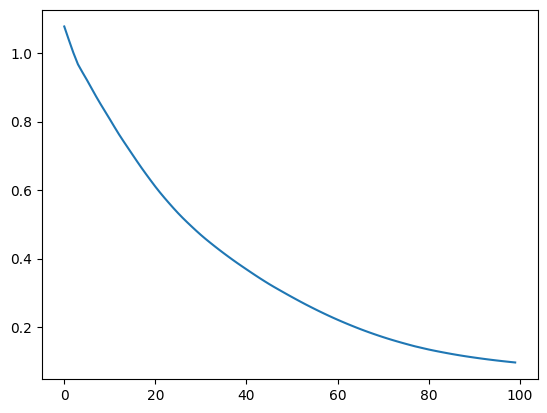

In [ ]:
plt.plot(range(epochs), loss_list)
plt.show()

## 모델 결과

In [ ]:
model(test_X).shape

torch.Size([30, 3])

In [ ]:
y_pred = model(test_X)

In [ ]:
y_pred.max(dim=0)

torch.return_types.max(
values=tensor([8.3024, 2.2042, 4.1954], grad_fn=<MaxBackward0>),
indices=tensor([11, 25, 15]))

In [ ]:
y_pred.max(dim=1) # 행을 기준으로

torch.return_types.max(
values=tensor([1.2864, 2.6892, 4.1544, 2.0148, 7.1129, 1.2593, 1.9749, 6.2909, 5.6413,
        1.4295, 1.6658, 8.3024, 1.5318, 2.4688, 3.4212, 4.1954, 7.4141, 6.3323,
        1.6323, 5.9459, 6.9222, 1.3241, 5.6364, 1.3913, 7.1274, 6.4629, 6.6898,
        2.9369, 3.4379, 7.1057], grad_fn=<MaxBackward0>),
indices=tensor([2, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2, 0, 2,
        0, 0, 0, 2, 2, 0]))

In [ ]:
# 값
y_pred.max(dim=1)[0]

tensor([1.2864, 2.6892, 4.1544, 2.0148, 7.1129, 1.2593, 1.9749, 6.2909, 5.6413,
        1.4295, 1.6658, 8.3024, 1.5318, 2.4688, 3.4212, 4.1954, 7.4141, 6.3323,
        1.6323, 5.9459, 6.9222, 1.3241, 5.6364, 1.3913, 7.1274, 6.4629, 6.6898,
        2.9369, 3.4379, 7.1057], grad_fn=<MaxBackward0>)

In [ ]:
# 인덱스
y_pred.max(dim=1)[1]

tensor([2, 2, 2, 1, 0, 2, 1, 0, 0, 1, 2, 0, 1, 2, 2, 2, 0, 0, 1, 0, 0, 2, 0, 2,
        0, 0, 0, 2, 2, 0])

In [ ]:
sum(y_pred.max(dim=1)[1] == test_y)

tensor(29)

In [ ]:
# 단일 텐서에서 값만 뽑기(여러 값이 들어있는 텐서는 tolist()나 numpy()로 바꿔야 됨)
sum(y_pred.max(dim=1)[1] == test_y).item()

29

## 검증

In [ ]:
len(test_y), test_y.size()

(30, torch.Size([30]))

In [ ]:
# 검증
model.eval()
correct = 0
total = len(test_y)
with torch.no_grad():
  y_pred = model(test_X)
  result = y_pred.max(dim=1)[1] # 3가지 카테고리 중 값이 가장 큰 것

  correct = sum(result == test_y).item()

accuracy = correct / total * 100
print(f'accuracy: {accuracy}')

accuracy: 96.66666666666667


In [ ]:
torch.save(model.state_dict(), 'iris.pth')

## 모델 불러오기

In [1]:
import torch
import torch.nn as nn

In [2]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(4, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 3)
    self.afunc = nn.ReLU()

  def forward(self, x):
    x = self.fc1(x)
    x = self.afunc(x)
    x = self.fc2(x)
    x = self.afunc(x)
    x = self.fc3(x)
    return x

load_model = Net()
load_model.load_state_dict(torch.load('iris.pth'))

<ipython-input-2-860a92a4176b>:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  load_model.load_state_dict(torch.load('iris.pth'))


<All keys matched successfully>

# 보스턴 데이터로
(회귀)

In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

False

## 데이터 가져오기

In [ ]:
from sklearn.datasets import fetch_openml

In [ ]:
dataset = fetch_openml(name='boston')
dataset

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)


{'data':         CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  \
 0    0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0   
 1    0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0   
 2    0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0   
 3    0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0   
 4    0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0   
 ..       ...   ...    ...  ...    ...    ...   ...     ...  ..    ...   
 501  0.06263   0.0  11.93    0  0.573  6.593  69.1  2.4786   1  273.0   
 502  0.04527   0.0  11.93    0  0.573  6.120  76.7  2.2875   1  273.0   
 503  0.06076   0.0  11.93    0  0.573  6.976  91.0  2.1675   1  273.0   
 504  0.10959   0.0  11.93    0  0.573  6.794  89.3  2.3889   1  273.0   
 505  0.04741   0.0  11.93    0  0.573  6.030  80.8  2.5050   1  273.0   
 
      PTRATIO       B  LSTAT  
 0       15.3  396.90   4.98  
 1       17.8  396.90   9.14  
 2       

In [ ]:
# data와 target 사용
X = dataset.data
y = dataset.target

In [ ]:
type(X)

pandas.core.frame.DataFrame

## 데이터 확인

In [ ]:
X.shape

(506, 13)

In [ ]:
y.shape

(506,)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
dtypes: category(2), float64(11)
memory usage: 45.1 KB


In [ ]:
# category 살펴보기
X.CHAS.unique()

['0', '1']
Categories (2, object): ['0', '1']

In [ ]:
# category 살펴보기
X.RAD.unique()

['1', '2', '3', '5', '4', '8', '6', '7', '24']
Categories (9, object): ['1', '2', '24', '3', ..., '5', '6', '7', '8']

In [ ]:
# 다 숫자이므로 category -> float
X.CHAS = X.CHAS.astype('float')
X.RAD = X.RAD.astype('float')

<ipython-input-17-1527d2881ab2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.CHAS = X.CHAS.astype('float')
<ipython-input-17-1527d2881ab2>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.RAD = X.RAD.astype('float')


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


## train, test 나누기

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=111)

In [ ]:
len(train_X), len(test_X), len(train_y), len(test_y)

(404, 102, 404, 102)

In [ ]:
type(train_X)

pandas.core.frame.DataFrame

## 타입 변환(데이터프레임 -> 토치)

In [ ]:
train_X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
162,1.83377,0.0,19.58,1.0,0.605,7.802,98.2,2.0407,5.0,403.0,14.7,389.61,1.92
242,0.10290,30.0,4.93,0.0,0.428,6.358,52.9,7.0355,6.0,300.0,16.6,372.75,11.22
53,0.04981,21.0,5.64,0.0,0.439,5.998,21.4,6.8147,4.0,243.0,16.8,396.90,8.43
316,0.31827,0.0,9.90,0.0,0.544,5.914,83.2,3.9986,4.0,304.0,18.4,390.70,18.33
434,13.91340,0.0,18.10,0.0,0.713,6.208,95.0,2.2222,24.0,666.0,20.2,100.63,15.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,0.05188,0.0,4.49,0.0,0.449,6.015,45.1,4.4272,3.0,247.0,18.5,395.99,12.86
212,0.21719,0.0,10.59,1.0,0.489,5.807,53.8,3.6526,4.0,277.0,18.6,390.94,16.03
468,15.57570,0.0,18.10,0.0,0.580,5.926,71.0,2.9084,24.0,666.0,20.2,368.74,18.13
364,3.47428,0.0,18.10,1.0,0.718,8.780,82.9,1.9047,24.0,666.0,20.2,354.55,5.29


In [ ]:
# 넘파이
train_X.values

array([[1.83377e+00, 0.00000e+00, 1.95800e+01, ..., 1.47000e+01,
        3.89610e+02, 1.92000e+00],
       [1.02900e-01, 3.00000e+01, 4.93000e+00, ..., 1.66000e+01,
        3.72750e+02, 1.12200e+01],
       [4.98100e-02, 2.10000e+01, 5.64000e+00, ..., 1.68000e+01,
        3.96900e+02, 8.43000e+00],
       ...,
       [1.55757e+01, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
        3.68740e+02, 1.81300e+01],
       [3.47428e+00, 0.00000e+00, 1.81000e+01, ..., 2.02000e+01,
        3.54550e+02, 5.29000e+00],
       [6.15100e-02, 0.00000e+00, 5.19000e+00, ..., 2.02000e+01,
        3.96900e+02, 9.29000e+00]])

In [ ]:
train_X = torch.tensor(train_X.values)
train_y = torch.tensor(train_y.values)
test_X = torch.tensor(test_X.values)
test_y = torch.tensor(test_y.values)

In [ ]:
train_X = train_X.type(torch.float32)
train_y = train_y.type(torch.float32)
test_X = test_X.type(torch.float32)
test_y = test_y.type(torch.float32)

## 모델 구조

13 -> 64 -> 32 -> 1

In [ ]:
import torch.nn as nn
import torch.optim as optim

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(13, 64)
    self.fc2 = nn.Linear(64, 32)
    self.fc3 = nn.Linear(32, 1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.fc2(x)
    x = self.fc3(x)
    return x

In [ ]:
model = Net()

In [ ]:
model

Net(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

## 모델 학습 및 검증

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.MSELoss()
epochs = 300

In [ ]:
loss_list = []
model.train()
for epoch in range(epochs):
  # 기울기 초기화
  optimizer.zero_grad()

  # 순전파
  y_pred = model(train_X)

  # 손실함수 계산
  loss = criterion(y_pred, train_y)

  # loss 표시
  print(f'epoch: {epoch+1}, loss: {loss.item()}')
  loss_list.append(loss.item())

  # 역전파
  loss.backward()

  # 파라미터 업데이트
  optimizer.step()

epoch: 1, loss: 757.1356201171875
epoch: 2, loss: 691.29345703125
epoch: 3, loss: 630.655517578125
epoch: 4, loss: 575.2828369140625
epoch: 5, loss: 525.2034912109375
epoch: 6, loss: 480.399169921875
epoch: 7, loss: 440.794677734375
epoch: 8, loss: 406.2493591308594
epoch: 9, loss: 376.5528869628906
epoch: 10, loss: 351.42864990234375
epoch: 11, loss: 330.5397033691406
epoch: 12, loss: 313.4936828613281
epoch: 13, loss: 299.8484191894531
epoch: 14, loss: 289.12200927734375
epoch: 15, loss: 280.807861328125
epoch: 16, loss: 274.3939208984375
epoch: 17, loss: 269.3839416503906
epoch: 18, loss: 265.31646728515625
epoch: 19, loss: 261.7823181152344
epoch: 20, loss: 258.43658447265625
epoch: 21, loss: 255.00587463378906
epoch: 22, loss: 251.29107666015625
epoch: 23, loss: 247.1648406982422
epoch: 24, loss: 242.56541442871094
epoch: 25, loss: 237.4882049560547
epoch: 26, loss: 231.97470092773438
epoch: 27, loss: 226.101318359375
epoch: 28, loss: 219.9678955078125
epoch: 29, loss: 213.6870117

In [ ]:
torch.save(model.state_dict(), 'boston.pth')

## loss 시각화

In [ ]:
import matplotlib.pyplot as plt

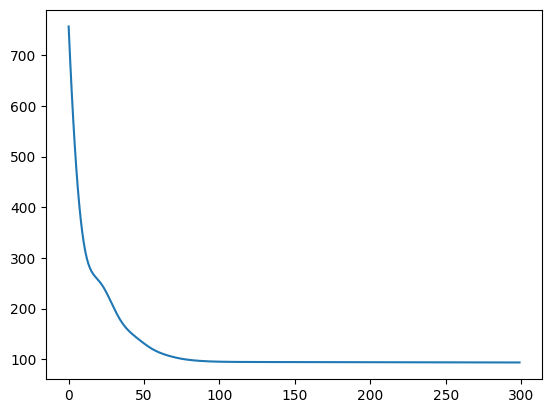

In [ ]:
plt.plot(range(epochs), loss_list)
plt.show()

## 모델 검증

In [ ]:
model.eval()
val_loss = 0
with torch.no_grad(): # 기울기 계산 비활성화
  y_pred = model(test_X)
  loss = criterion(y_pred, test_y)
  val_loss += loss.item()
print(f"Validation Loss(MSE): {val_loss:.4f}")

Validation Loss(MSE): 104.5307


In [ ]:
test_X.shape

torch.Size([102, 13])

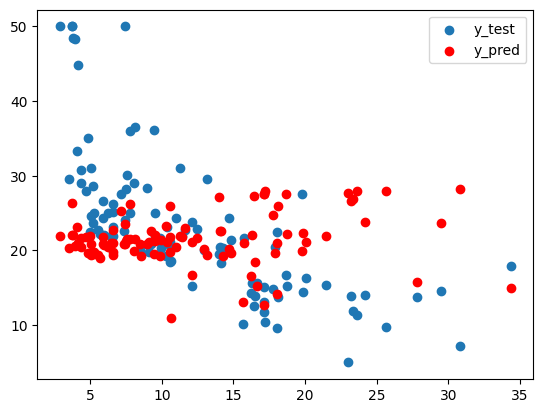

In [ ]:
#예측값과 실제값의 분포
plt.scatter(test_X[:, 12], test_y, label='y_test')  #파란점, 실제값
plt.scatter(test_X[:, 12], y_pred, c='r', label='y_pred')  #빨간점, 예측값
plt.legend(loc='best')  #범례(오른쪽 상단 박스)가 표시되는 위치 지정
plt.show()